# Logistic Regression — Perlidae and Helicopsychidae

Binary logistic regression models for the presence/absence of the two bioindicator
taxa (*Plecoptera: Perlidae* and *Trichoptera: Helicopsychidae*) in the Cali River,
validated with leave-one-out cross-validation (LOOCV). Predictor selection follows
the Spearman rank correlation criterion constrained to a single predictor per the
Events Per Variable (EPV) principle.

## 1. Introduction

Two single-predictor logistic regression models are fitted, one for each bioindicator
taxon. Within each LOOCV fold the candidate predictors are screened by absolute
Spearman rank correlation (|ρₛ|) computed on the n−1 training observations, and
exactly one predictor — the one with the highest |ρₛ| — is retained. This
one-predictor constraint follows from the Events Per Variable (EPV) criterion:
Perlidae has 6 presence events (EPV = 6) and Helicopsychidae has 3 (EPV = 3) across
n = 18 observations, both insufficient to support more than one predictor reliably.
Each model is evaluated under nested LOOCV, and both calibration (training-fold) and
validation (held-out) metrics are reported. Class imbalance is handled with balanced
class weights.

## 2. Dependencies and Data Loading

The macroinvertebrate dataset (n = 18) provides the physicochemical predictors and
the binary presence/absence of `Perlidae` and `Trichoptera` (Helicopsychidae).

In [60]:
# Imports and global plotting style
import numpy as np
import pandas as pd
import statsmodels.api as sm
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (confusion_matrix, classification_report, cohen_kappa_score,
                             precision_recall_fscore_support, accuracy_score)
from collections import Counter
from IPython.display import Markdown, display
import warnings
warnings.filterwarnings("ignore")
sns.set_style('whitegrid')

In [61]:
# Load the macroinvertebrate dataset (relative path)
df = pd.read_excel("../../data/DB - Macroinvertebrados.xlsx")
df.columns = df.columns.str.strip()
print("Shape:", df.shape)
print("Perlidae +/-:", df['Perlidae'].value_counts().to_dict())
print("Helicopsychidae (Trichoptera) +/-:", df['Trichoptera'].value_counts().to_dict())

Shape: (18, 24)
Perlidae +/-: {0: 12, 1: 6}
Helicopsychidae (Trichoptera) +/-: {0: 15, 1: 3}


## 3. Predictor Candidates

Seven physicochemical variables are considered as candidate predictors: `DBO5`,
`Dureza`, `Caudal`, `Turbiedad`, `OD`, `Magnesio`, and `COT`. This set spans oxygen
demand, mineral hardness, flow regime, turbidity, dissolved oxygen, magnesium
concentration, and total organic carbon, covering the main axes of water-quality
variation relevant to macroinvertebrate assemblages in tropical rivers
(Rios-Touma et al., 2014). The actual predictor used in each LOOCV fold is determined
by within-fold Spearman screening as described in Section 4.

In [62]:
# Seven physicochemical candidate predictors
candidate_predictors = ['DBO5', 'Dureza', 'Caudal', 'Turbiedad', 'OD', 'Magnesio', 'COT']
print("Candidate predictors:", candidate_predictors)
print(f"n = {len(df)}")
print(f"Perlidae presence events:        {int(df['Perlidae'].sum())}  →  EPV with 1 predictor = {int(df['Perlidae'].sum()):.1f}")
print(f"Helicopsychidae presence events: {int(df['Trichoptera'].sum())}  →  EPV with 1 predictor = {int(df['Trichoptera'].sum()):.1f}")

Candidate predictors: ['DBO5', 'Dureza', 'Caudal', 'Turbiedad', 'OD', 'Magnesio', 'COT']
n = 18
Perlidae presence events:        6  →  EPV with 1 predictor = 6.0
Helicopsychidae presence events: 3  →  EPV with 1 predictor = 3.0


## 4. Methodological Justification

### 4.1  Why Spearman rank correlation for predictor screening

Physicochemical variables measured in tropical river systems characteristically
exhibit skewed, non-normal distributions driven by seasonal flood pulses,
anthropogenic discharges, and geochemical heterogeneity (Zuur et al., 2009).
Under such distributional conditions, Pearson correlation can distort monotonic
relationships because it assumes bivariate normality and is sensitive to outliers.
Spearman rank correlation (ρₛ) requires neither normality nor linearity: it quantifies
monotonic association by operating on ranks rather than raw values, making it robust
to the heavy tails and occasional extreme observations typical of field-collected
hydrochemical data (Zuur et al., 2009; Legendre & Legendre, 2012).

With n−1 = 17 training observations per LOOCV fold, parametric model-selection
criteria such as AIC computed from binomial GLMs risk convergence failures,
quasi-perfect separation, and inflated coefficient estimates when the number of events
is low relative to the candidate pool (King & Zeng, 2001). Spearman screening,
applied pairwise and without model fitting, avoids these pathologies and remains
numerically stable across all 18 training partitions.

### 4.2  EPV criterion and the one-predictor limit

The Events Per Variable (EPV) ratio is defined as the number of outcome events
(minority-class observations) divided by the number of estimated regression
coefficients (excluding the intercept). Vittinghoff & McCulloch (2007) demonstrated
through simulation that EPV values below 5–10 produce unstable coefficient estimates,
inflated standard errors, and unreliable likelihood-ratio tests in logistic
regression. More recent work shows that for rare events (prevalence < 20 %) and
correlated predictors, even EPV = 10 may be insufficient and the minimum requirement
scales with the degree of imbalance (van Smeden et al., 2016).

In this dataset the observed EPV for each taxon is:

| Taxon | Presence events | n | EPV — 1 predictor | EPV — 2 predictors |
|-------|----------------|---|-------------------|---------------------|
| Perlidae | 6 | 18 | **6.0** | 3.0 |
| Helicopsychidae | 3 | 18 | **3.0** | 1.5 |

Perlidae reaches EPV = 6 with one predictor, which sits at the lower bound of the
marginally adequate range identified by Vittinghoff & McCulloch (2007). Adding a
second predictor halves EPV to 3.0, well below any published threshold. For
Helicopsychidae, EPV = 3 with a single predictor already falls in the high-risk zone;
any additional predictor would reduce EPV below 2, rendering coefficient estimation
essentially unreliable. Restricting each LOOCV fold to exactly one predictor —
the candidate with the highest |ρₛ| on the training rows — is therefore the
methodologically sound maximum for both taxa.

**References**

- King, G. & Zeng, L. (2001). Logistic regression in rare events data. *Political
  Analysis*, 9(2), 137–163.
- Legendre, P. & Legendre, L. (2012). *Numerical Ecology* (3rd ed.). Elsevier.
- Rios-Touma, B., Encalada, A. C. & Prat, N. (2014). Macroinvertebrate assemblages of
  an Andean high-altitude tropical stream: the importance of season and flow. *Journal
  of Freshwater Ecology*, 26(3), 357–371.
- van Smeden, M., de Groot, J. A. H., Moons, K. G. M., Collins, G. S., Altman, D. G.,
  Eijkemans, M. J. C. & Reitsma, J. B. (2016). No rationale for 1 variable per 10
  events criterion for binary logistic regression. *BMC Medical Research Methodology*,
  16, 163.
- Vittinghoff, E. & McCulloch, C. E. (2007). Relaxing the rule of ten events per
  variable in logistic and Cox regression. *American Journal of Epidemiology*, 165(6),
  710–718.
- Zuur, A. F., Ieno, E. N., Walker, N., Saveliev, A. A. & Smith, G. M. (2009).
  *Mixed Effects Models and Extensions in Ecology with R*. Springer.

## 5. Predictor Selection Methodology

### 5.1 AIC vs Spearman: criterion comparison

Before selecting the number of predictors k, the selection criterion itself is
evaluated. Two competing approaches are compared under full nested LOOCV: exhaustive
AIC selection (all non-empty subsets of the seven candidates fitted as binomial GLMs,
retaining the subset that minimises AIC) and Spearman rank screening (top-k by |ρₛ|,
with k = 1 for this initial comparison). Both methods operate strictly inside each
LOOCV fold using only the n−1 = 17 training observations; all other modelling choices
are held constant, isolating the selection criterion as the sole variable. The
rationale for preferring Spearman over AIC in this dataset is documented in Section 4.

In [63]:
# Shared metric helper
def met(yt, yp):
    p, r, f, _ = precision_recall_fscore_support(yt, yp, labels=[0, 1],
                                                  average='macro', zero_division=0)
    return dict(precision=p, recall=r, f1=f,
                accuracy=accuracy_score(yt, yp),
                kappa=cohen_kappa_score(yt, yp))

# ── AIC-based nested LOOCV (exhaustive binomial GLM subset selection) ──────────
def select_by_aic_nested(train_df, candidates, response):
    best_aic, best_combo = np.inf, None
    for L in range(1, len(candidates) + 1):
        for subset in combinations(candidates, L):
            X_sub = sm.add_constant(train_df[list(subset)])
            y_sub = train_df[response]
            try:
                result = sm.GLM(y_sub, X_sub,
                                 family=sm.families.Binomial()).fit(disp=False)
                if result.aic < best_aic:
                    best_aic, best_combo = result.aic, subset
            except Exception:
                continue
    return list(best_combo)

def run_aic_loocv(y_col):
    yt_val, yp_val, sel = [], [], []
    for tr, te in LeaveOneOut().split(np.arange(len(df))):
        train = df.iloc[tr]
        selected = select_by_aic_nested(train, candidate_predictors, y_col)
        sel.append(selected)
        scaler = StandardScaler().fit(train[selected].values)
        X_tr = scaler.transform(train[selected].values)
        X_te = scaler.transform(df.iloc[te][selected].values)
        m = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000,
                               random_state=42, class_weight='balanced')
        m.fit(X_tr, train[y_col].values)
        yt_val.append(int(df.iloc[te][y_col].values[0]))
        yp_val.append(int(m.predict(X_te)[0]))
    return {'yt_val': yt_val, 'yp_val': yp_val, 'sel': sel}

nested_aic = {
    'Perlidae':        run_aic_loocv('Perlidae'),
    'Helicopsychidae': run_aic_loocv('Trichoptera'),
}
print("AIC-based nested LOOCV complete.")

AIC-based nested LOOCV complete.


In [64]:
# ── Spearman nested LOOCV — k sets the number of top-|ρₛ| predictors per fold ─
def select_by_spearman_epv(train_df, candidates, response, k=1):
    """Return k candidates with the highest absolute Spearman |ρₛ|, sorted
    alphabetically so the same set always maps to the same tuple."""
    rs = {c: abs(spearmanr(train_df[c], train_df[response])[0]) for c in candidates}
    top_k = sorted(rs, key=rs.get, reverse=True)[:k]
    return sorted(top_k)   # alphabetical order for consistent tuple comparison

def run_spearman_loocv(y_col, k=1):
    yt_val, yp_val = [], []
    yt_cal, yp_cal = [], []
    sel_per_fold, coef_records = [], []
    for tr, te in LeaveOneOut().split(np.arange(len(df))):
        train = df.iloc[tr]
        preds = select_by_spearman_epv(train, candidate_predictors, y_col, k=k)
        sel_per_fold.append(tuple(preds))
        scaler = StandardScaler().fit(train[preds].values)
        X_tr   = scaler.transform(train[preds].values)
        X_te   = scaler.transform(df.iloc[te][preds].values)
        m = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000,
                               random_state=42, class_weight='balanced')
        m.fit(X_tr, train[y_col].values)
        # Back-transform coefficients to original (unscaled) predictor units
        mus    = [float(train[p].mean()) for p in preds]
        sigmas = [float(train[p].std())  for p in preds]
        b_raw  = [m.coef_[0][i] / sigmas[i] for i in range(k)]
        b0_raw = float(m.intercept_[0]) - sum(
            m.coef_[0][i] * mus[i] / sigmas[i] for i in range(k))
        coef_records.append({'predictors': list(preds), 'b0': b0_raw, 'b': b_raw})
        yt_cal.extend(train[y_col].tolist())
        yp_cal.extend(m.predict(X_tr).tolist())
        yt_val.append(int(df.iloc[te][y_col].values[0]))
        yp_val.append(int(m.predict(X_te)[0]))
    return {'yt_val': yt_val, 'yp_val': yp_val,
            'yt_cal': yt_cal, 'yp_cal': yp_cal,
            'sel': sel_per_fold, 'coefs': coef_records}

# k=1 for the Section 5.1 criterion comparison (Spearman side of AIC vs Spearman)
nested_sp = {
    'Perlidae':        run_spearman_loocv('Perlidae',    k=1),
    'Helicopsychidae': run_spearman_loocv('Trichoptera', k=1),
}
print("Spearman (k=1) nested LOOCV complete — for criterion comparison in Section 5.1.")

Spearman (k=1) nested LOOCV complete — for criterion comparison in Section 5.1.


In [65]:
# Side-by-side AIC vs Spearman (k=1) criterion comparison
# sel now stores tuples; '+'.join(tuple) works for both k=1 and k>1
md_lines = [
    '| Taxon | Selection | Accuracy | Kappa | Precision | Recall | F1 | Modal predictor(s) |',
    '|-------|-----------|----------|-------|-----------|--------|----|-------------------|',
]
for taxon, y_col in [('Perlidae', 'Perlidae'), ('Helicopsychidae', 'Trichoptera')]:
    m_aic = met(nested_aic[taxon]['yt_val'], nested_aic[taxon]['yp_val'])
    m_sp  = met(nested_sp[taxon]['yt_val'],  nested_sp[taxon]['yp_val'])
    modal_aic = Counter(tuple(s) for s in nested_aic[taxon]['sel']).most_common(1)[0]
    modal_sp  = Counter(nested_sp[taxon]['sel']).most_common(1)[0]
    md_lines.append(
        f"| {taxon} | AIC | {m_aic['accuracy']:.3f} | {m_aic['kappa']:.3f} | "
        f"{m_aic['precision']:.3f} | {m_aic['recall']:.3f} | {m_aic['f1']:.3f} | "
        f"{'+'.join(modal_aic[0])} ×{modal_aic[1]}/18 |")
    md_lines.append(
        f"| {taxon} | Spearman k=1 | {m_sp['accuracy']:.3f} | {m_sp['kappa']:.3f} | "
        f"{m_sp['precision']:.3f} | {m_sp['recall']:.3f} | {m_sp['f1']:.3f} | "
        f"{'+'.join(modal_sp[0])} ×{modal_sp[1]}/18 |")
display(Markdown('\n'.join(md_lines)))

| Taxon | Selection | Accuracy | Kappa | Precision | Recall | F1 | Modal predictor(s) |
|-------|-----------|----------|-------|-----------|--------|----|-------------------|
| Perlidae | AIC | 0.722 | 0.444 | 0.722 | 0.750 | 0.714 | Caudal+Turbiedad ×15/18 |
| Perlidae | Spearman k=1 | 0.556 | 0.250 | 0.714 | 0.667 | 0.550 | Turbiedad ×18/18 |
| Helicopsychidae | AIC | 0.444 | -0.111 | 0.444 | 0.400 | 0.375 | Caudal+OD ×11/18 |
| Helicopsychidae | Spearman k=1 | 0.556 | 0.111 | 0.556 | 0.600 | 0.500 | Caudal ×17/18 |

### 5.2 Spearman sensitivity: selecting k

With Spearman confirmed as the selection criterion, the optimal number of predictors
k is determined empirically by running nested LOOCV for k = 1, 2, and 3. This
data-driven approach is consistent with the exploratory nature of the study under
severe data scarcity: fixing k a priori without empirical validation would be
arbitrary given the small sample and extreme class imbalance.

**Perlidae (6 presence events).** The sensitivity analysis reveals monotonic
improvement in Cohen's κ across k: κ = 0.250 (k = 1) → 0.276 (k = 2) → 0.483
(k = 3). This monotonic gain supports k = 3 as the final choice. The associated EPV
of 2.0 falls below the conventional threshold of 5–10 (Vittinghoff & McCulloch,
2007); however, nested LOOCV partially mitigates overfitting risk by ensuring that
predictor selection and model fitting are always performed on the n−1 training
observations without access to the held-out point (Harrell, 2015). EPV = 2.0 is
explicitly acknowledged as a limitation (Section 10) and the choice is treated as a
deliberate trade-off between estimation stability and predictive performance.

**Helicopsychidae (3 presence events).** Model performance collapses at k ≥ 2
(κ < 0), providing empirical confirmation that additional predictors cannot be
supported by three presence events. This result reinforces the EPV constraint
documented in Section 4: two independent lines of evidence — the EPV criterion and
the observed performance collapse — converge on k = 1, strengthening the decision.

**Selected k per taxon:**

| Taxon | k | EPV | κ (validation) | Rationale |
|-------|---|-----|----------------|-----------|
| Perlidae | **3** | 2.0 | 0.483 | Monotonic κ improvement; nested LOOCV mitigates EPV risk |
| Helicopsychidae | **1** | 3.0 | 0.111 | EPV + empirical collapse at k > 1 |

**Reference**

- Harrell, F. E. (2015). *Regression Modeling Strategies: With Applications to
  Linear Models, Logistic and Ordinal Regression, and Survival Analysis* (2nd ed.).
  Springer.

In [66]:
# ── Sensitivity: nested LOOCV for k = 1, 2, 3 top-Spearman predictors ────────
# Exploration only — no CSV or figure written.
# Variables prefixed with _ to avoid overwriting any existing notebook object.
_rows = []
for _k in [1, 2, 3]:
    for _taxon, _y_col in [('Perlidae', 'Perlidae'), ('Helicopsychidae', 'Trichoptera')]:
        _yt_val, _yp_val, _sel_per_fold = [], [], []
        for _tr, _te in LeaveOneOut().split(np.arange(len(df))):
            _train = df.iloc[_tr]
            _rs = {c: abs(spearmanr(_train[c], _train[_y_col])[0])
                   for c in candidate_predictors}
            _top = sorted(_rs, key=_rs.get, reverse=True)[:_k]
            _sel_per_fold.append(tuple(_top))
            _scaler = StandardScaler().fit(_train[_top].values)
            _X_tr = _scaler.transform(_train[_top].values)
            _X_te = _scaler.transform(df.iloc[_te][_top].values)
            _m = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000,
                                    random_state=42, class_weight='balanced')
            _m.fit(_X_tr, _train[_y_col].values)
            _yt_val.append(int(df.iloc[_te][_y_col].values[0]))
            _yp_val.append(int(_m.predict(_X_te)[0]))
        _modal_combo, _modal_n = Counter(_sel_per_fold).most_common(1)[0]
        _rows.append({
            'k':                  _k,
            'Taxon':              _taxon,
            'Accuracy':           round(accuracy_score(_yt_val, _yp_val), 3),
            'Kappa':              round(cohen_kappa_score(_yt_val, _yp_val), 3),
            'Modal predictor(s)': '+'.join(_modal_combo) + f' ×{_modal_n}/18',
        })

_hdr = f"{'k':>2}  {'Taxon':<16} {'Accuracy':>8} {'Kappa':>7}  Modal predictor(s)"
print(_hdr)
print('-' * 70)
for _r in _rows:
    print(f"{_r['k']:>2}  {_r['Taxon']:<16} {_r['Accuracy']:>8.3f} "
          f"{_r['Kappa']:>7.3f}  {_r['Modal predictor(s)']}")

 k  Taxon            Accuracy   Kappa  Modal predictor(s)
----------------------------------------------------------------------
 1  Perlidae            0.556   0.250  Turbiedad ×18/18
 1  Helicopsychidae     0.556   0.111  Caudal ×17/18
 2  Perlidae            0.611   0.276  Turbiedad+DBO5 ×16/18
 2  Helicopsychidae     0.444  -0.304  Caudal+DBO5 ×10/18
 3  Perlidae            0.722   0.483  Turbiedad+DBO5+Dureza ×16/18
 3  Helicopsychidae     0.500  -0.080  Caudal+DBO5+OD ×10/18


### 5.3 Definitive configuration

Based on the sensitivity analysis, the definitive predictor-selection configuration
is:

| Taxon | k | EPV | Criterion | κ (validation) |
|-------|---|-----|-----------|----------------|
| Perlidae | **3** | 2.0 | Spearman, top-3 | 0.483 |
| Helicopsychidae | **1** | 3.0 | Spearman, top-1 | 0.111 |

These taxon-specific values are used in all subsequent sections. Section 6 reports
the definitive nested LOOCV results under this configuration. The EPV = 2.0 for
Perlidae is a declared limitation addressed in Section 10.

## 6. Final Results — Nested LOOCV with Taxon-Specific k

The definitive evaluation uses the taxon-specific configuration identified in
Section 5: Perlidae k = 3, Helicopsychidae k = 1. Predictor selection and model
fitting are performed exclusively on the n−1 training observations of each fold;
the held-out observation contributes only to the validation prediction, eliminating
data leakage. Calibration metrics aggregate training-fold predictions across all 18
folds; validation metrics summarise the 18 held-out predictions.

In [67]:
# Recompute with the definitive taxon-specific k values from Section 5
nested_sp = {
    'Perlidae':        run_spearman_loocv('Perlidae',    k=3),
    'Helicopsychidae': run_spearman_loocv('Trichoptera', k=1),
}
print("Definitive Spearman nested LOOCV complete (Perlidae k=3, Helicopsychidae k=1).\n")

# Per-fold predictor selection summary
for taxon in ['Perlidae', 'Helicopsychidae']:
    sel = nested_sp[taxon]['sel']
    modal_set, modal_n = Counter(sel).most_common(1)[0]
    fold_df = pd.DataFrame({'Fold': range(1, 19),
                            'Selected predictors': ['+'.join(s) for s in sel]})
    print(f"=== {taxon}: modal set '{'+'.join(modal_set)}' in {modal_n}/18 folds ===")
    display(fold_df)

Definitive Spearman nested LOOCV complete (Perlidae k=3, Helicopsychidae k=1).

=== Perlidae: modal set 'DBO5+Dureza+Turbiedad' in 18/18 folds ===


,Fold,Selected predictors
0,1,DBO5+Dureza+Turbiedad
1,2,DBO5+Dureza+Turbiedad
2,3,DBO5+Dureza+Turbiedad
3,4,DBO5+Dureza+Turbiedad
4,5,DBO5+Dureza+Turbiedad
5,6,DBO5+Dureza+Turbiedad
6,7,DBO5+Dureza+Turbiedad
7,8,DBO5+Dureza+Turbiedad
8,9,DBO5+Dureza+Turbiedad
9,10,DBO5+Dureza+Turbiedad


=== Helicopsychidae: modal set 'Caudal' in 17/18 folds ===


,Fold,Selected predictors
0,1,Caudal
1,2,Caudal
2,3,Caudal
3,4,Caudal
4,5,Caudal
5,6,Caudal
6,7,Caudal
7,8,Caudal
8,9,Caudal
9,10,Caudal


## 7. Evaluation — Calibration

Calibration metrics aggregate training-fold predictions across all 18 LOOCV folds
(18 folds × 17 training rows each). High calibration performance is expected because
each model is evaluated on the same data used to fit it.

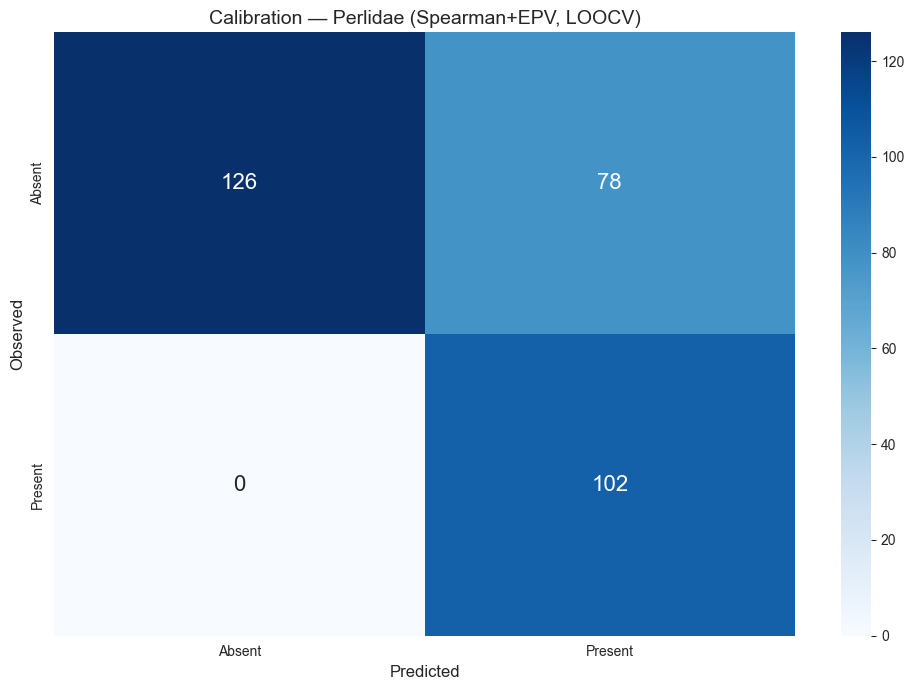

              precision    recall  f1-score   support

      Absent       1.00      0.62      0.76       204
     Present       0.57      1.00      0.72       102

    accuracy                           0.75       306
   macro avg       0.78      0.81      0.74       306
weighted avg       0.86      0.75      0.75       306

Cohen's Kappa (calibration): 0.519


In [68]:
# Standardised confusion-matrix plotter
def plot_confusion(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 16},
                xticklabels=['Absent', 'Present'], yticklabels=['Absent', 'Present'])
    plt.title(title, fontsize=14)
    plt.xlabel('Predicted', fontsize=12); plt.ylabel('Observed', fontsize=12)
    plt.tight_layout()
    plt.savefig(f"../../outputs/{filename}", dpi=300)
    plt.show()

# Perlidae — calibration confusion matrix and report
res = nested_sp['Perlidae']
plot_confusion(res['yt_cal'], res['yp_cal'],
               'Calibration — Perlidae (Spearman+EPV, LOOCV)',
               'logistic_perlidae_confusion_matrix_calibration.png')
print(classification_report(res['yt_cal'], res['yp_cal'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (calibration): {cohen_kappa_score(res['yt_cal'], res['yp_cal']):.3f}")

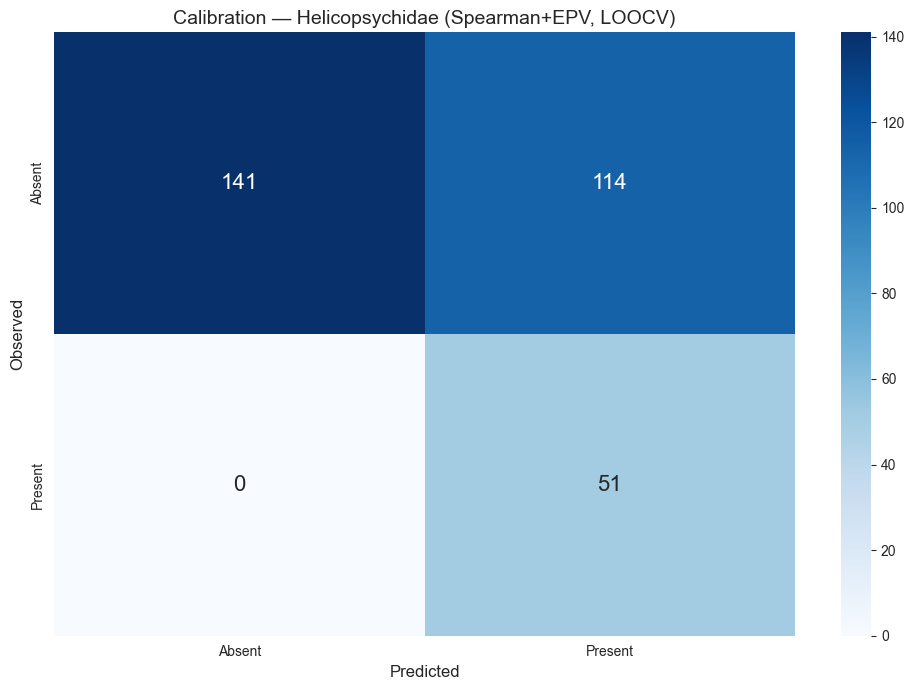

              precision    recall  f1-score   support

      Absent       1.00      0.55      0.71       255
     Present       0.31      1.00      0.47        51

    accuracy                           0.63       306
   macro avg       0.65      0.78      0.59       306
weighted avg       0.88      0.63      0.67       306

Cohen's Kappa (calibration): 0.292


In [69]:
# Helicopsychidae — calibration confusion matrix and report
res = nested_sp['Helicopsychidae']
plot_confusion(res['yt_cal'], res['yp_cal'],
               'Calibration — Helicopsychidae (Spearman+EPV, LOOCV)',
               'logistic_helicopsychidae_confusion_matrix_calibration.png')
print(classification_report(res['yt_cal'], res['yp_cal'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (calibration): {cohen_kappa_score(res['yt_cal'], res['yp_cal']):.3f}")

## 8. Evaluation — Validation (LOOCV)

Validation metrics use the held-out observation from each of the 18 LOOCV folds,
providing an honest estimate of out-of-sample performance. Each prediction is made
by a model that has never seen the held-out observation — neither for fitting nor for
predictor selection.

### Note on Helicopsychidae performance

With only 3 presences in 18 observations (17 %), LOOCV cannot reliably estimate
minority-class generalisation. Validation metrics for this taxon should be interpreted
with caution; Cohen's κ is the most informative single metric under such imbalance
because it accounts for chance agreement.

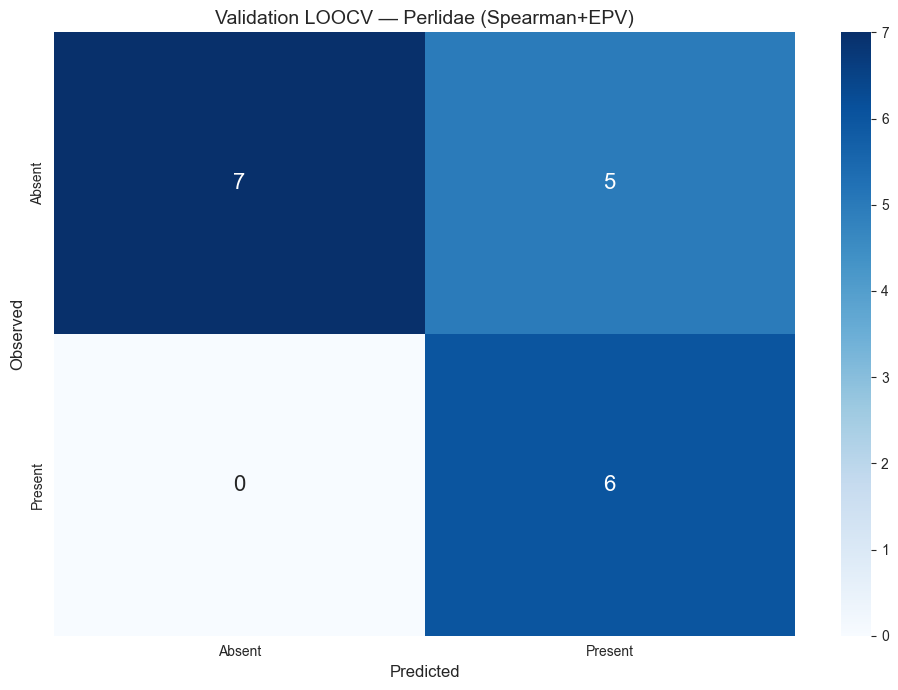

              precision    recall  f1-score   support

      Absent       1.00      0.58      0.74        12
     Present       0.55      1.00      0.71         6

    accuracy                           0.72        18
   macro avg       0.77      0.79      0.72        18
weighted avg       0.85      0.72      0.73        18

Cohen's Kappa (validation): 0.483


In [70]:
# Perlidae — validation confusion matrix, classification report, Cohen's kappa
res = nested_sp['Perlidae']
plot_confusion(res['yt_val'], res['yp_val'],
               'Validation LOOCV — Perlidae (Spearman+EPV)',
               'logistic_perlidae_confusion_matrix_validation.png')
print(classification_report(res['yt_val'], res['yp_val'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (validation): {cohen_kappa_score(res['yt_val'], res['yp_val']):.3f}")

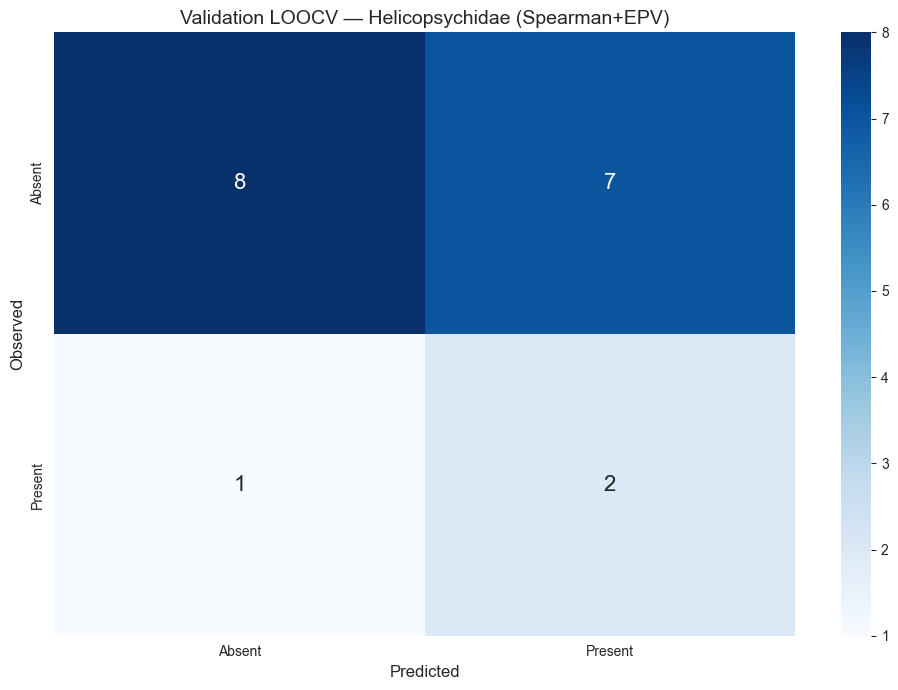

              precision    recall  f1-score   support

      Absent       0.89      0.53      0.67        15
     Present       0.22      0.67      0.33         3

    accuracy                           0.56        18
   macro avg       0.56      0.60      0.50        18
weighted avg       0.78      0.56      0.61        18

Cohen's Kappa (validation): 0.111


In [71]:
# Helicopsychidae — validation confusion matrix, classification report, Cohen's kappa
res = nested_sp['Helicopsychidae']
plot_confusion(res['yt_val'], res['yp_val'],
               'Validation LOOCV — Helicopsychidae (Spearman+EPV)',
               'logistic_helicopsychidae_confusion_matrix_validation.png')
print(classification_report(res['yt_val'], res['yp_val'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (validation): {cohen_kappa_score(res['yt_val'], res['yp_val']):.3f}")

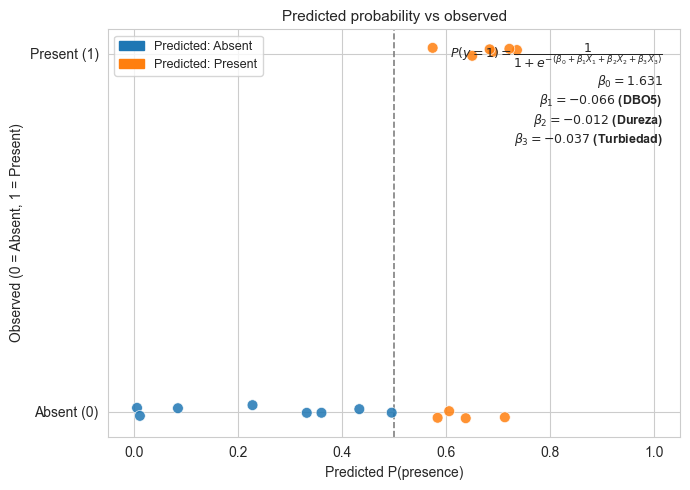

Saved logistic_curve_perlidae.png  |  modal set: DBO5+Dureza+Turbiedad  ×18/18


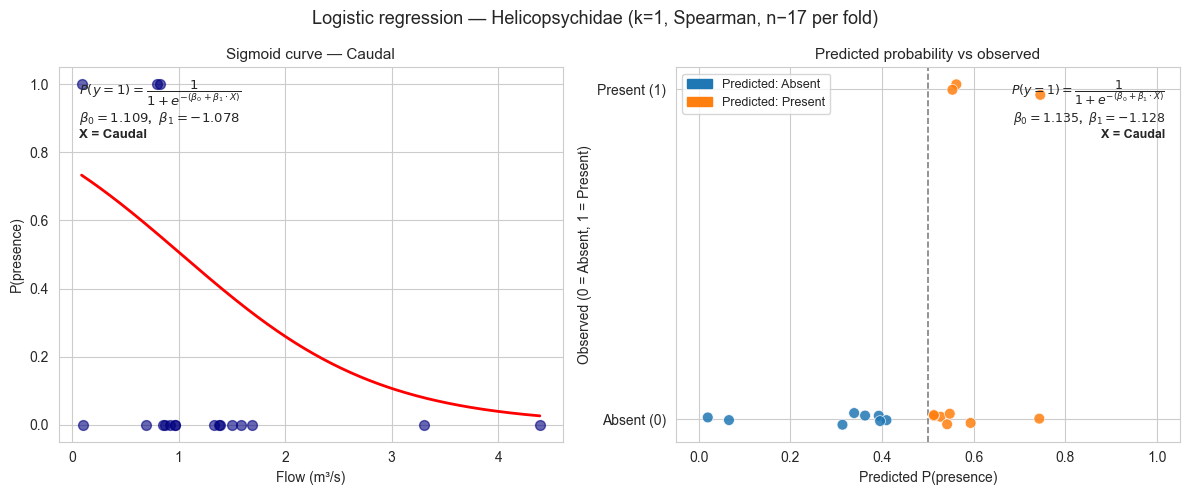

Saved logistic_curve_helicopsychidae.png  |  modal set: Caudal  ×17/18


In [72]:
import matplotlib.patches as mpatches

XLABEL = {'DBO5': 'BOD₅ (mg/L)', 'Caudal': 'Flow (m³/s)',
          'Dureza': 'Hardness (mg/L CaCO₃)', 'OD': 'DO (mg/L)',
          'Turbiedad': 'Turbidity (NTU)', 'Magnesio': 'Magnesium (mg/L)',
          'COT': 'TOC (mg/L)'}


def _modal_coefs(coef_records):
    """(modal_set_tuple, matching_records, count)"""
    modal_set, modal_n = Counter(
        tuple(r['predictors']) for r in coef_records
    ).most_common(1)[0]
    recs = [r for r in coef_records if tuple(r['predictors']) == modal_set]
    return modal_set, recs, modal_n


def _fit_all(y_col, preds):
    """Refit on all 18 obs; return back-transformed coefficients + per-obs proba."""
    scaler = StandardScaler().fit(df[preds].values)
    X_all  = scaler.transform(df[preds].values)
    m = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000,
                           random_state=42, class_weight='balanced')
    m.fit(X_all, df[y_col].values)
    k      = len(preds)
    sigmas = [float(df[p].std())  for p in preds]
    mus    = [float(df[p].mean()) for p in preds]
    b_raw  = [m.coef_[0][i] / sigmas[i] for i in range(k)]
    b0_raw = float(m.intercept_[0]) - sum(
        m.coef_[0][i] * mus[i] / sigmas[i] for i in range(k))
    proba      = m.predict_proba(X_all)[:, 1]
    pred_class = m.predict(X_all)
    return b0_raw, b_raw, proba, pred_class


def _pred_obs_ax(ax, proba, y_obs, pred_class, b0, b_list, preds):
    """Draw predicted-probability vs observed panel onto ax."""
    rng    = np.random.default_rng(42)
    jitter = rng.uniform(-0.02, 0.02, size=len(y_obs))
    colors = ['#1f77b4' if pc == 0 else '#ff7f0e' for pc in pred_class]

    ax.scatter(proba, y_obs + jitter, c=colors, s=60, alpha=0.85, zorder=3,
               edgecolors='white', linewidths=0.5)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=1.2, zorder=2)

    leg_handles = [
        mpatches.Patch(color='#1f77b4', label='Predicted: Absent'),
        mpatches.Patch(color='#ff7f0e', label='Predicted: Present'),
    ]
    ax.legend(handles=leg_handles, fontsize=9, loc='upper left')
    ax.set_xlabel('Predicted P(presence)', fontsize=10)
    ax.set_ylabel('Observed (0 = Absent, 1 = Present)', fontsize=10)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Absent (0)', 'Present (1)'])
    ax.set_xlim(-0.05, 1.05)
    ax.set_title('Predicted probability vs observed', fontsize=11)

    # ── Equation annotation: bold, transparent background ─────────────────────
    k = len(preds)
    if k == 1:
        eq1 = (r'$P(y=1) = \dfrac{1}{1 + e^{-(\beta_0 + \beta_1 \cdot X)}}$')
        coef_str = (f'$\\beta_0={b0:.3f}$,  $\\beta_1={b_list[0]:.3f}$'
                    f'\nX = {preds[0]}')
    else:
        subscripts = ''.join([f' + \\beta_{i+1} X_{i+1}' for i in range(k)])
        eq1 = f'$P(y=1) = \\dfrac{{1}}{{1 + e^{{-(\\beta_0{subscripts})}}}}$'
        coef_str = f'$\\beta_0={b0:.3f}$\n' + '\n'.join(
            [f'$\\beta_{i+1}={b_list[i]:.3f}$ ({preds[i]})' for i in range(k)])
    ax.text(0.97, 0.97, eq1 + '\n' + coef_str,
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            fontweight='bold',
            bbox=dict(facecolor='none', edgecolor='none'))


# ── Perlidae: single predicted-probability vs observed plot ────────────────────
def plot_perlidae_predobs(coef_records, y_col, save_fname):
    modal_set, modal_recs, modal_n = _modal_coefs(coef_records)
    preds  = list(modal_set)
    b0, b_list, proba, pred_class = _fit_all(y_col, preds)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.set_title(
        'Logistic regression — Perlidae (k=3, Spearman, n−17 per fold)',
        fontsize=12)
    _pred_obs_ax(ax, proba, df[y_col].values, pred_class, b0, b_list, preds)

    plt.tight_layout()
    plt.savefig(f'../../outputs/{save_fname}', dpi=300)
    plt.show()
    print(f'Saved {save_fname}  |  modal set: {"+".join(modal_set)}  \xd7{modal_n}/18')


# ── Helicopsychidae: sigmoid (left) + predicted vs observed (right) ────────────
def plot_helicopsychidae_panel(coef_records, y_col, save_fname):
    modal_set, modal_recs, modal_n = _modal_coefs(coef_records)
    preds = list(modal_set)   # k=1 → ['Caudal']
    pred  = preds[0]

    b0_med = float(np.median([r['b0']    for r in modal_recs]))
    b1_med = float(np.median([r['b'][0]  for r in modal_recs]))
    b0_all, b_list_all, proba, pred_class = _fit_all(y_col, preds)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(
        'Logistic regression — Helicopsychidae (k=1, Spearman, n−17 per fold)',
        fontsize=13)

    # Left panel — sigmoid curve
    ax = axes[0]
    x_raw  = df[pred].values
    x_grid = np.linspace(x_raw.min(), x_raw.max(), 400)
    p_grid = 1.0 / (1.0 + np.exp(-(b0_med + b1_med * x_grid)))
    ax.scatter(x_raw, df[y_col].values, color='navy', alpha=0.6, s=50, zorder=3)
    ax.plot(x_grid, p_grid, color='red', linewidth=2)
    eq1 = r'$P(y=1) = \dfrac{1}{1 + e^{-(\beta_0 + \beta_1 \cdot X)}}$'
    eq2 = f'$\\beta_0={b0_med:.3f}$,  $\\beta_1={b1_med:.3f}$\nX = {pred}'
    ax.text(0.04, 0.97, eq1 + '\n' + eq2,
            transform=ax.transAxes, fontsize=9.5,
            verticalalignment='top', fontweight='bold',
            bbox=dict(facecolor='none', edgecolor='none'))
    ax.set_xlabel(XLABEL.get(pred, pred), fontsize=10)
    ax.set_ylabel('P(presence)', fontsize=10)
    ax.set_title(f'Sigmoid curve — {pred}', fontsize=11)

    # Right panel — predicted probability vs observed
    _pred_obs_ax(axes[1], proba, df[y_col].values, pred_class,
                 b0_all, b_list_all, preds)

    plt.tight_layout()
    plt.savefig(f'../../outputs/{save_fname}', dpi=300)
    plt.show()
    print(f'Saved {save_fname}  |  modal set: {"+".join(modal_set)}  \xd7{modal_n}/18')


plot_perlidae_predobs(nested_sp['Perlidae']['coefs'], 'Perlidae',
                      'logistic_curve_perlidae.png')
plot_helicopsychidae_panel(nested_sp['Helicopsychidae']['coefs'], 'Trichoptera',
                           'logistic_curve_helicopsychidae.png')

In [73]:
# Export definitive validation metrics (Perlidae k=3, Helicopsychidae k=1)
rows = []
for taxon, y_col in [('Perlidae', 'Perlidae'), ('Helicopsychidae', 'Trichoptera')]:
    res = nested_sp[taxon]
    p, r, f, _ = precision_recall_fscore_support(
        res['yt_val'], res['yp_val'], labels=[0, 1], average='macro', zero_division=0)
    modal_set, modal_n = Counter(res['sel']).most_common(1)[0]
    k = len(modal_set)
    rows.append({
        'target':              taxon,
        'technique':           'Logistic regression',
        'selection':           f'Spearman top-{k}',
        'validation':          'Nested LOOCV',
        'n':                   18,
        'k':                   k,
        'precision':           round(p, 3),
        'recall':              round(r, 3),
        'f1':                  round(f, 3),
        'accuracy':            round(accuracy_score(res['yt_val'], res['yp_val']), 3),
        'kappa':               round(cohen_kappa_score(res['yt_val'], res['yp_val']), 3),
        'modal_predictors':    '+'.join(modal_set),
        'predictor_stability': f"{modal_n}/18",
    })
out_df = pd.DataFrame(rows)
out_df.to_csv("../../outputs/metrics_logistic_nested_loocv.csv", index=False)
print("Saved outputs/metrics_logistic_nested_loocv.csv")
print(out_df.to_string(index=False))

Saved outputs/metrics_logistic_nested_loocv.csv
         target           technique      selection   validation  n  k  precision  recall    f1  accuracy  kappa      modal_predictors predictor_stability
       Perlidae Logistic regression Spearman top-3 Nested LOOCV 18  3      0.773   0.792 0.721     0.722  0.483 DBO5+Dureza+Turbiedad               18/18
Helicopsychidae Logistic regression Spearman top-1 Nested LOOCV 18  1      0.556   0.600 0.500     0.556  0.111                Caudal               17/18


## 9. Predictor Stability

Because Spearman screening is re-run independently inside each of the 18 LOOCV
folds, the selected predictor set can vary across folds. The table below counts how
often each candidate appeared in the active set per taxon (Perlidae k = 3;
Helicopsychidae k = 1), revealing which variables are most consistently informative
across the training partitions.

In [74]:
# Predictor stability: count folds in which each predictor appeared across all taxa
for taxon in ['Perlidae', 'Helicopsychidae']:
    pred_counts = Counter()
    for tup in nested_sp[taxon]['sel']:
        pred_counts.update(tup)       # each element of the tuple is one predictor name
    k = len(nested_sp[taxon]['sel'][0])
    stab = pd.DataFrame({
        'Predictor': candidate_predictors,
        f'{taxon} (k={k}) — folds selected (of 18)': [
            pred_counts.get(p, 0) for p in candidate_predictors],
    }).sort_values(f'{taxon} (k={k}) — folds selected (of 18)',
                   ascending=False).reset_index(drop=True)
    print(f"=== {taxon} ===")
    display(stab)

=== Perlidae ===


,Predictor,Perlidae (k=3) — folds selected (of 18)
0,DBO5,18
1,Dureza,18
2,Turbiedad,18
3,Caudal,0
4,OD,0
5,Magnesio,0
6,COT,0


=== Helicopsychidae ===


,Predictor,Helicopsychidae (k=1) — folds selected (of 18)
0,Caudal,17
1,COT,1
2,DBO5,0
3,Dureza,0
4,Turbiedad,0
5,OD,0
6,Magnesio,0


## 10. Limitations

**Small sample and class imbalance.** The dataset contains 18 observations with
marked class imbalance (Perlidae: 6 presence events; Helicopsychidae: 3 presence
events). Class imbalance is addressed by `class_weight='balanced'`, which reweights
the loss function inversely proportional to class frequency (King & Zeng, 2001). All
performance metrics are macro-averaged; Cohen's κ is the primary metric because
accuracy is uninformative under imbalance.

**EPV — Perlidae (EPV = 2.0).** With k = 3 predictors and 6 minority-class events,
the Events Per Variable ratio is EPV = 6 / 3 = 2.0, below the conventional floor of
5–10 (Vittinghoff & McCulloch, 2007; van Smeden et al., 2016). Three factors
mitigate — but do not eliminate — this risk: (i) nested LOOCV ensures predictor
selection and model fitting never access the held-out observation, providing an honest
generalisation estimate; (ii) L2 regularisation shrinks coefficients toward zero,
reducing variance; and (iii) the monotonic κ improvement (0.250 → 0.276 → 0.483 for
k = 1, 2, 3) provides empirical support for the choice. Under cross-validation, EPV
constraints are less stringent than in single-split analyses (Harrell, 2015). The
choice to proceed with k = 3 is a deliberate trade-off, acknowledged here as a
limitation.

**EPV — Helicopsychidae (EPV = 3.0).** With k = 1 and 3 presence events, EPV = 3.0.
Two independent lines of evidence support retaining a single predictor: first, the
EPV criterion rules out k ≥ 2 on sample-size grounds; second, the sensitivity
analysis confirmed performance collapse at k ≥ 2 (κ < 0). The convergence of these
two sources of evidence strengthens confidence in the k = 1 decision despite the very
small minority class.

**Spatial non-independence.** Stations lie along one river reach, so LOOCV folds are
not fully independent; effective sample size is lower than n = 18.

**Generalisation.** All models are trained on one Colombian Andean stream system.
Predictive performance for other basins, river types, or seasons is unknown and should
not be assumed.

**References**

- Harrell, F. E. (2015). *Regression Modeling Strategies* (2nd ed.). Springer.
- King, G., & Zeng, L. (2001). Logistic regression in rare events data. *Political
  Analysis*, 9(2), 137–163.
- van Smeden, M., et al. (2016). No rationale for 1 variable per 10 events criterion
  for binary logistic regression. *BMC Medical Research Methodology*, 16, 163.
- Vittinghoff, E., & McCulloch, C. E. (2007). Relaxing the rule of ten events per
  variable in logistic and Cox regression. *American Journal of Epidemiology*,
  165(6), 710–718.